# 🎬 CT255H - Movie Recommendation System (Version 2)
## NexConflict - Hệ thống Đề xuất Phim sử dụng Machine Learning

---

**📚 Môn học:** CT255H - Nghiệp vụ thông minh (Business Intelligence)

**🏫 Trường:** Đại học Cần Thơ - Trường Công nghệ thông tin và Truyền Thông

**📅 Năm học:** 2024-2025

---

### 👥 Thành viên nhóm
| STT | Họ và Tên | MSSV |
|-----|-----------|------|
| 1 | Nguyễn Thành Trọng | B2305615 |
| 2 | Cao Tường Hưng | B2303873 |

---

### 📋 Mục lục
1. [Giới thiệu đề tài](#1-giới-thiệu-đề-tài)
2. [Setup & Cài đặt môi trường](#2-setup--cài-đặt-môi-trường)
3. [Dataset và Tiền xử lý](#3-dataset-và-tiền-xử-lý)
4. [Trực quan hóa dữ liệu](#4-trực-quan-hóa-dữ-liệu)
5. [Collaborative Filtering - SVD](#5-collaborative-filtering---svd)
6. [Content-Based Filtering](#6-content-based-filtering)
7. [Đánh giá Model](#7-đánh-giá-model)
8. [Lưu Model & Kết luận](#8-lưu-model--kết-luận)

---

### 🆕 Phiên bản 2 - Cải tiến
- ✅ Giải thích chi tiết trước mỗi cell code
- ✅ Trực quan hóa dữ liệu sau khi tiền xử lý
- ✅ Chỉ giữ phim từ năm 2000 trở đi
- ✅ Tối ưu cho Google Colab

---
# 1. Giới thiệu đề tài

## 1.1. Bối cảnh

Trong thời đại số, lượng nội dung phim ảnh tăng nhanh chóng khiến người dùng gặp khó khăn trong việc tìm kiếm phim phù hợp với sở thích. **Hệ thống đề xuất (Recommendation System)** đóng vai trò quan trọng trong việc cá nhân hóa trải nghiệm người dùng.

## 1.2. Mục tiêu

Xây dựng hệ thống đề xuất phim sử dụng hai phương pháp chính:

| Phương pháp | Mô tả | Thuật toán |
|-------------|-------|------------|
| **Collaborative Filtering** | Dựa trên hành vi đánh giá của người dùng | SVD (Matrix Factorization) |
| **Content-Based Filtering** | Dựa trên đặc điểm nội dung phim | Cosine Similarity + TF-IDF |

## 1.3. Kiến trúc hệ thống

```
┌─────────────────────────────────────────────────────────────┐
│                    NexConflict Architecture                 │
├─────────────────────────────────────────────────────────────┤
│  Frontend          │  Backend           │  AI Service       │
│  (Next.js 15)      │  (Spring Boot)     │  (FastAPI)        │
│  Port: 3000        │  Port: 8080        │  Port: 5000       │
├─────────────────────────────────────────────────────────────┤
│                      Data Layer                             │
│              MovieLens Dataset (Filtered)                   │
│           ⚠️ Chỉ phim từ năm 2000 trở đi                    │
└─────────────────────────────────────────────────────────────┘
```

---
# 2. Setup & Cài đặt môi trường

## 2.1. Giải thích

Phần này cài đặt các thư viện cần thiết cho notebook:

| Thư viện | Mục đích |
|----------|----------|
| `scikit-surprise` | Thư viện chuyên dụng cho Recommender System (SVD, KNN, NMF) |
| `pandas` | Xử lý và phân tích dữ liệu dạng bảng |
| `numpy` | Tính toán số học, ma trận |
| `scikit-learn` | Các công cụ ML như TF-IDF, Cosine Similarity |
| `matplotlib`, `seaborn` | Trực quan hóa dữ liệu |
| `joblib` | Lưu/tải model đã train |

⚠️ **Lưu ý:** Surprise yêu cầu NumPy < 2.0 để tương thích.

In [1]:
# ==========================================
# CELL 1: CÀI ĐẶT THƯ VIỆN
# ==========================================
# Giải thích:
# - Cài đặt numpy < 2.0 vì thư viện surprise chưa hỗ trợ numpy 2.x
# - scikit-surprise là thư viện chính cho Collaborative Filtering
# - Các thư viện khác dùng cho xử lý dữ liệu và visualization

!pip install "numpy<2" -q
!pip install scikit-surprise==1.1.4 -q
!pip install pandas scikit-learn joblib matplotlib seaborn wordcloud -q

print("✅ Đã cài đặt xong các thư viện!")

✅ Đã cài đặt xong các thư viện!


## 2.2. Mount Google Drive

**Mục đích:** Kết nối Google Drive để:
- Load dữ liệu MovieLens đã upload lên Drive
- Lưu model đã train để sử dụng sau

⚠️ **Hành động cần thiết:** Thay đổi `PROJECT_DIR` theo đường dẫn thực tế trên Drive của bạn.

In [2]:
# ==========================================
# CELL 2: MOUNT GOOGLE DRIVE
# ==========================================
# Giải thích:
# - Mount Google Drive để truy cập dữ liệu
# - Tạo thư mục models/ nếu chưa tồn tại để lưu model

from google.colab import drive
drive.mount('/content/drive')

# ⚠️ THAY ĐỔI đường dẫn này theo cấu trúc Drive của bạn
PROJECT_DIR = '/content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project'
DATA_DIR = f'{PROJECT_DIR}/data'
MODEL_DIR = f'{PROJECT_DIR}/modelsv2'

import os
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"📁 Project directory: {PROJECT_DIR}")
print(f"📁 Data directory: {DATA_DIR}")
print(f"📁 Model directory: {MODEL_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Project directory: /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project
📁 Data directory: /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project/data
📁 Model directory: /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project/modelsv2


## 2.3. Import thư viện

Import tất cả thư viện cần thiết:
- **Surprise:** Cho Collaborative Filtering (SVD, KNN, ...)
- **Scikit-learn:** Cho Content-Based (TF-IDF, Cosine Similarity)
- **Matplotlib/Seaborn:** Cho visualization

In [3]:
# ==========================================
# CELL 3: IMPORT THƯ VIỆN
# ==========================================
# Giải thích các thư viện chính:
# - pandas: Xử lý DataFrame (bảng dữ liệu)
# - numpy: Tính toán ma trận
# - surprise: Thư viện Collaborative Filtering (SVD, KNN)
# - sklearn: TF-IDF, Cosine Similarity cho Content-Based
# - matplotlib, seaborn: Vẽ biểu đồ

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import re
import warnings
warnings.filterwarnings('ignore')

# Surprise library cho Collaborative Filtering
from surprise import Dataset, Reader, SVD, SVDpp, NMF, KNNBasic, KNNWithMeans
from surprise.model_selection import cross_validate, train_test_split, GridSearchCV
from surprise import accuracy

# Scikit-learn cho Content-Based Filtering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split as sklearn_split

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Color palette
COLORS = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

print("✅ Import thư viện thành công!")
print(f"📦 Pandas version: {pd.__version__}")
print(f"📦 NumPy version: {np.__version__}")

✅ Import thư viện thành công!
📦 Pandas version: 2.2.2
📦 NumPy version: 1.26.4


---
# 3. Dataset và Tiền xử lý

## 3.1. Giới thiệu MovieLens Dataset

**MovieLens 20M** là bộ dữ liệu benchmark chuẩn trong nghiên cứu Recommender Systems, được thu thập bởi GroupLens Research.

### Cấu trúc dữ liệu gốc

| File | Mô tả | Số lượng |
|------|-------|----------|
| `ratings.csv` | Đánh giá của users | ~20 triệu ratings |
| `movies.csv` | Thông tin phim | ~27,000 phim |
| `genome-scores.csv` | Tag relevance scores | ~12 triệu rows |
| `genome-tags.csv` | Danh sách tags | 1,128 tags |

### ⚠️ Lọc dữ liệu

Để phù hợp với mục tiêu đề xuất phim **hiện đại**, dữ liệu đã được lọc:
- **Chỉ giữ phim từ năm 2000 trở đi**
- Loại bỏ phim cũ và ratings tương ứng

**Nguồn:** https://grouplens.org/datasets/movielens/20m/

In [4]:
# ==========================================
# CELL 4: LOAD DỮ LIỆU
# ==========================================
# Giải thích:
# - Load ratings.csv: Chứa thông tin đánh giá (userId, movieId, rating, timestamp)
# - Load movies.csv: Chứa metadata phim (movieId, title, genres)
# - Thử load genome data nếu có (cho content-based nâng cao)
#
# Tham số MAX_RATINGS:
# - Set = None để load toàn bộ dữ liệu
# - Set = 500000 để test nhanh (giảm thời gian train)

print("📊 Đang load dữ liệu (đã lọc - chỉ phim từ 2000+)...")
start_time = time.time()

# ⚠️ Thay đổi MAX_RATINGS để test nhanh hoặc load toàn bộ
MAX_RATINGS = None  # None = load toàn bộ, hoặc 500000 để test nhanh

ratings_df = pd.read_csv(f'{DATA_DIR}/ratings.csv', nrows=MAX_RATINGS)
movies_df = pd.read_csv(f'{DATA_DIR}/movies.csv')

# Load genome data nếu có
try:
    genome_scores = pd.read_csv(f'{DATA_DIR}/genome_scores.csv')
    genome_tags = pd.read_csv(f'{DATA_DIR}/genome_tags.csv')
    HAS_GENOME = True
    print("✅ Đã load genome data")
except:
    HAS_GENOME = False
    print("⚠️ Không tìm thấy genome data, sẽ dùng TF-IDF genres")

load_time = time.time() - start_time
print(f"\n⏱️ Thời gian load: {load_time:.2f} giây")

📊 Đang load dữ liệu (đã lọc - chỉ phim từ 2000+)...
✅ Đã load genome data

⏱️ Thời gian load: 28.70 giây


## 3.2. Xác nhận lọc dữ liệu theo năm

**Mục đích:** Kiểm tra xem dữ liệu đã được lọc đúng chưa (chỉ giữ phim từ năm 2000+).

**Phương pháp:** Trích xuất năm từ title phim (format: "Movie Name (YYYY)") bằng regex.

In [5]:
# ==========================================
# CELL 5: XÁC NHẬN LỌC DỮ LIỆU THEO NĂM
# ==========================================
# Giải thích:
# - Hàm extract_year() dùng regex để trích xuất năm từ title
# - Kiểm tra xem có phim nào trước năm 2000 không
# - Hiển thị thống kê năm phát hành

def extract_year(title):
    """Trích xuất năm từ title (format: Movie Name (YYYY))"""
    if pd.isna(title):
        return None
    match = re.search(r'\((\d{4})\)', str(title))
    if match:
        year = int(match.group(1))
        if 1900 <= year <= 2030:
            return year
    return None

# Parse năm từ title
movies_df['year'] = movies_df['title'].apply(extract_year)

print("=" * 60)
print("📅 XÁC NHẬN LỌC DỮ LIỆU THEO NĂM")
print("=" * 60)

print(f"\n📊 Thống kê năm phát hành:")
print(f"   - Năm sớm nhất: {int(movies_df['year'].min())}")
print(f"   - Năm mới nhất: {int(movies_df['year'].max())}")
print(f"   - Năm trung bình: {movies_df['year'].mean():.0f}")
print(f"   - Năm median: {movies_df['year'].median():.0f}")

# Kiểm tra có phim nào trước 2000 không
pre_2000 = movies_df[movies_df['year'] < 2000]
if len(pre_2000) == 0:
    print(f"\n✅ XÁC NHẬN: Tất cả {len(movies_df):,} phim đều từ năm 2000 trở đi!")
else:
    print(f"\n⚠️ CẢNH BÁO: Có {len(pre_2000)} phim trước năm 2000")

📅 XÁC NHẬN LỌC DỮ LIỆU THEO NĂM

📊 Thống kê năm phát hành:
   - Năm sớm nhất: 2000
   - Năm mới nhất: 2015
   - Năm trung bình: 2008
   - Năm median: 2008

✅ XÁC NHẬN: Tất cả 12,746 phim đều từ năm 2000 trở đi!


## 3.3. Khám phá dữ liệu Ratings

**Thống kê quan trọng:**
- **Số lượng ratings, users, movies**
- **Sparsity:** Tỷ lệ ô trống trong ma trận User-Item (thường > 95%)
- **Phân phối rating:** Người dùng có xu hướng đánh giá cao hay thấp?

In [6]:
# ==========================================
# CELL 6: KHÁM PHÁ DỮ LIỆU RATINGS
# ==========================================
# Giải thích:
# - Đếm số ratings, users, movies
# - Tính Sparsity = tỷ lệ ô trống trong ma trận User-Item
#   (Sparsity cao = dữ liệu thưa = khó dự đoán)
# - Hiển thị sample data và thống kê rating

print("=" * 60)
print("📊 THỐNG KÊ RATINGS DATASET")
print("=" * 60)

n_ratings = len(ratings_df)
n_users = ratings_df['userId'].nunique()
n_movies_rated = ratings_df['movieId'].nunique()
n_movies_total = len(movies_df)

print(f"\n📌 Kích thước: {ratings_df.shape}")
print(f"📌 Số ratings: {n_ratings:,}")
print(f"📌 Số users: {n_users:,}")
print(f"📌 Số movies được rate: {n_movies_rated:,}")
print(f"📌 Tổng số movies: {n_movies_total:,}")

# Tính sparsity (tỷ lệ ô trống trong ma trận User-Item)
sparsity = 1 - n_ratings / (n_users * n_movies_rated)
print(f"📌 Sparsity: {sparsity:.4%}")
print(f"   → Ma trận User-Item có {sparsity:.2%} ô trống")

# Tính ratings trung bình mỗi user và mỗi movie
avg_ratings_per_user = n_ratings / n_users
avg_ratings_per_movie = n_ratings / n_movies_rated
print(f"\n📊 Trung bình mỗi user đánh giá: {avg_ratings_per_user:.1f} phim")
print(f"📊 Trung bình mỗi phim nhận được: {avg_ratings_per_movie:.1f} ratings")

print("\n" + "=" * 60)
print("📋 SAMPLE DATA (10 dòng đầu)")
print("=" * 60)
display(ratings_df.head(10))

print("\n" + "=" * 60)
print("📈 THỐNG KÊ RATING")
print("=" * 60)
display(ratings_df['rating'].describe())

📊 THỐNG KÊ RATINGS DATASET

📌 Kích thước: (5282121, 4)
📌 Số ratings: 5,282,121
📌 Số users: 87,851
📌 Số movies được rate: 12,547
📌 Tổng số movies: 12,746
📌 Sparsity: 99.5208%
   → Ma trận User-Item có 99.52% ô trống

📊 Trung bình mỗi user đánh giá: 60.1 phim
📊 Trung bình mỗi phim nhận được: 421.0 ratings

📋 SAMPLE DATA (10 dòng đầu)


,userId,movieId,rating,timestamp
0,1,3889,4.0,2005-04-02 23:55:38
1,1,3996,4.0,2004-09-10 03:08:47
2,1,3997,3.5,2005-04-02 23:56:32
3,1,4011,4.0,2005-04-02 23:43:26
4,1,4027,4.0,2005-04-02 23:44:20
5,1,4226,3.5,2005-04-02 23:28:13
6,1,4306,4.0,2004-09-10 03:09:44
7,1,4446,3.5,2005-04-02 23:52:50
8,1,4720,3.5,2004-09-10 03:13:28
9,1,4878,3.5,2005-04-02 23:28:57



📈 THỐNG KÊ RATING


,rating
count,5.282121e+06
mean,3.498373e+00
std,1.028472e+00
min,5.000000e-01
25%,3.000000e+00
50%,3.500000e+00
75%,4.000000e+00
max,5.000000e+00


## 3.4. Khám phá dữ liệu Movies

**Thông tin cần biết:**
- **Cấu trúc genres:** Một phim có thể thuộc nhiều thể loại (Action|Adventure|Sci-Fi)
- **Top genres phổ biến**
- **Phân phối số phim theo năm**

In [7]:
# ==========================================
# CELL 7: KHÁM PHÁ DỮ LIỆU MOVIES
# ==========================================
# Giải thích:
# - Hiển thị sample movies
# - Đếm số phim theo từng genre
# - Tính số genres trung bình mỗi phim

print("=" * 60)
print("🎬 THỐNG KÊ MOVIES DATASET")
print("=" * 60)

print(f"\n📌 Tổng số phim: {len(movies_df):,}")
print(f"📌 Columns: {list(movies_df.columns)}")

print("\n📋 Sample movies:")
display(movies_df.head(10))

# Phân tích genres
print("\n" + "=" * 60)
print("🎭 PHÂN TÍCH GENRES")
print("=" * 60)

# Tách genres và đếm
all_genres = []
for genres in movies_df['genres'].dropna():
    all_genres.extend(genres.split('|'))

genre_counts = pd.Series(all_genres).value_counts()
print(f"\n📊 Số lượng genres khác nhau: {len(genre_counts)}")
print(f"\n📈 Top 10 genres phổ biến:")
for genre, count in genre_counts.head(10).items():
    print(f"   {genre}: {count:,} phim")

# Tính số genres trung bình mỗi phim
avg_genres_per_movie = movies_df['genres'].apply(lambda x: len(x.split('|')) if pd.notna(x) else 0).mean()
print(f"\n📊 Trung bình mỗi phim có: {avg_genres_per_movie:.1f} genres")

🎬 THỐNG KÊ MOVIES DATASET

📌 Tổng số phim: 12,746
📌 Columns: ['movieId', 'title', 'genres', 'year']

📋 Sample movies:


,movieId,title,genres,year
0,2769,"Yards, The (2000)",Crime|Drama,2000
1,3177,Next Friday (2000),Comedy,2000
2,3190,Supernova (2000),Adventure|Sci-Fi|Thriller,2000
3,3225,Down to You (2000),Comedy|Romance,2000
4,3228,Wirey Spindell (2000),Comedy,2000
5,3239,Isn't She Great? (2000),Comedy,2000
6,3273,Scream 3 (2000),Comedy|Horror|Mystery|Thriller,2000
7,3275,"Boondock Saints, The (2000)",Action|Crime|Drama|Thriller,2000
8,3276,Gun Shy (2000),Comedy,2000
9,3279,Knockout (2000),Action|Drama,2000



🎭 PHÂN TÍCH GENRES

📊 Số lượng genres khác nhau: 20

📈 Top 10 genres phổ biến:
   Drama: 6,158 phim
   Comedy: 3,875 phim
   Thriller: 2,296 phim
   Documentary: 1,865 phim
   Romance: 1,781 phim
   Action: 1,698 phim
   Crime: 1,309 phim
   Horror: 1,246 phim
   Adventure: 966 phim
   Sci-Fi: 763 phim

📊 Trung bình mỗi phim có: 2.0 genres


---
# 4. Trực quan hóa dữ liệu

## 4.1. Tại sao cần trực quan hóa?

Visualization giúp:
- **Hiểu phân phối dữ liệu:** Ratings nghiêng về cao hay thấp?
- **Phát hiện outliers:** Users rate quá nhiều/ít?
- **Xác định patterns:** Năm nào có nhiều phim? Genre nào phổ biến?

Phần này sẽ vẽ các biểu đồ sau:
1. **Phân phối Rating** (Histogram)
2. **Số phim theo năm** (Line chart)
3. **Top Genres** (Bar chart)
4. **Phân phối số ratings/user** (Histogram)
5. **Heatmap Rating theo Genre**

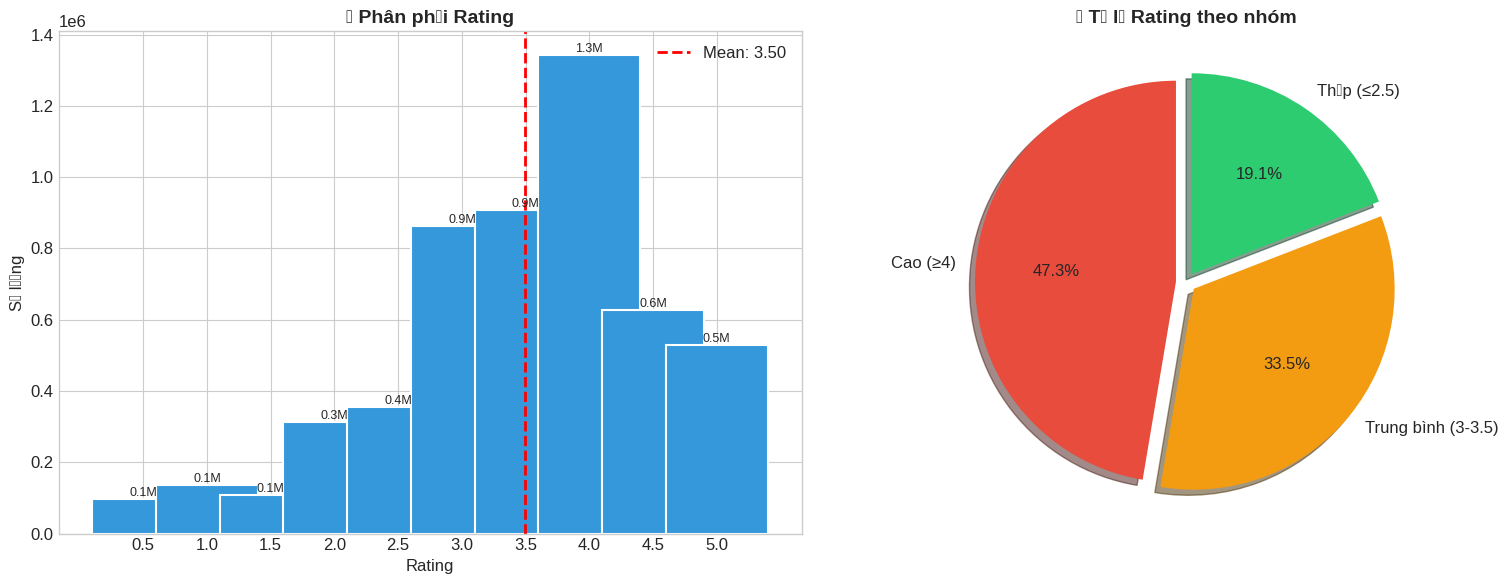

💾 Đã lưu: viz_rating_distribution.png


In [8]:
# ==========================================
# CELL 8: PHÂN PHỐI RATING
# ==========================================
# Giải thích:
# - Histogram cho thấy số lượng ratings ở mỗi mức (0.5 - 5.0)
# - Ratings thường nghiêng về phía cao (positive skew)
# - Vạch đỏ = rating trung bình

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Histogram phân phối rating
ax1 = axes[0]
rating_counts = ratings_df['rating'].value_counts().sort_index()
ax1.bar(rating_counts.index, rating_counts.values, color=COLORS[0], edgecolor='white', linewidth=1.5)
ax1.axvline(x=ratings_df['rating'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {ratings_df['rating'].mean():.2f}")
ax1.set_xlabel('Rating')
ax1.set_ylabel('Số lượng')
ax1.set_title('📊 Phân phối Rating', fontsize=14, fontweight='bold')
ax1.legend()
ax1.set_xticks([0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5])

# Thêm số liệu trên cột
for i, (rating, count) in enumerate(rating_counts.items()):
    ax1.annotate(f'{count/1e6:.1f}M', (rating, count), ha='center', va='bottom', fontsize=9)

# 2. Pie chart tỷ lệ rating
ax2 = axes[1]
rating_groups = pd.cut(ratings_df['rating'], bins=[0, 2.5, 3.5, 5], labels=['Thấp (≤2.5)', 'Trung bình (3-3.5)', 'Cao (≥4)'])
group_counts = rating_groups.value_counts()
ax2.pie(group_counts.values, labels=group_counts.index, autopct='%1.1f%%',
        colors=[COLORS[1], COLORS[3], COLORS[2]], explode=[0.05, 0.05, 0.05],
        shadow=True, startangle=90)
ax2.set_title('📈 Tỷ lệ Rating theo nhóm', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/viz_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Đã lưu: viz_rating_distribution.png")

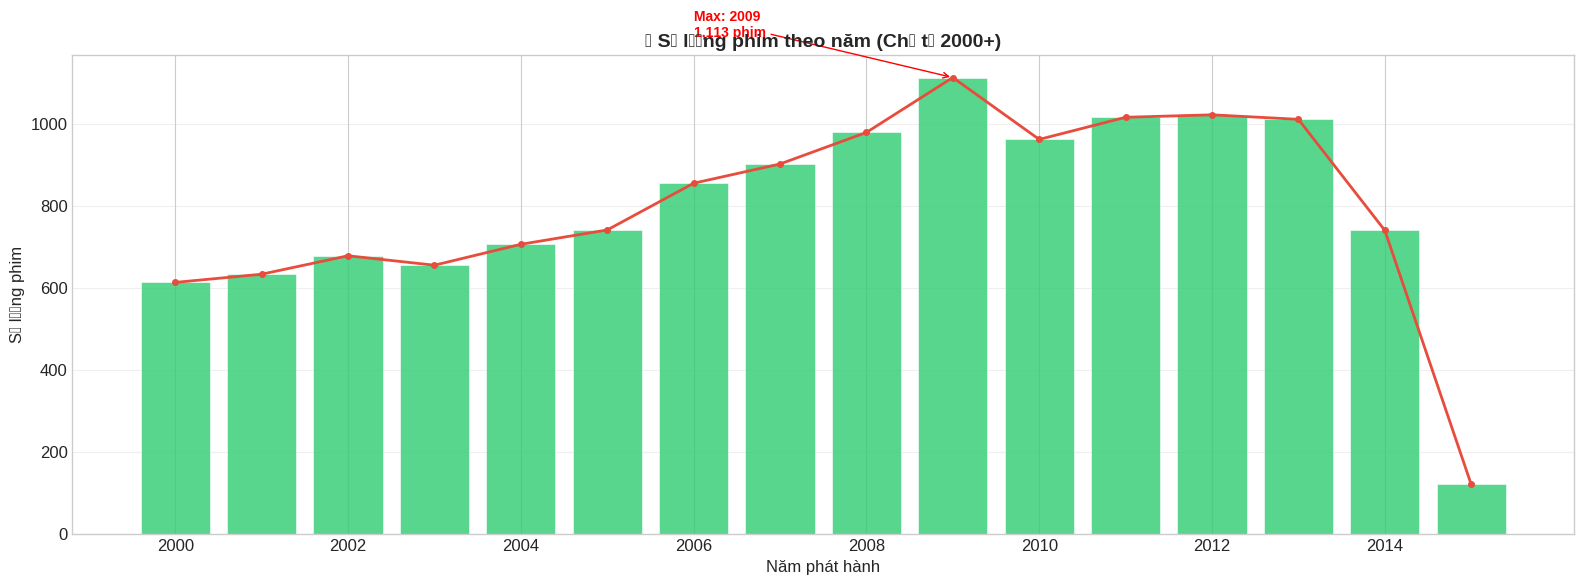


📊 Năm có nhiều phim nhất: 2009 với 1,113 phim
📊 Tổng số năm: 16 (từ 2000 đến 2015)
💾 Đã lưu: viz_movies_by_year.png


In [9]:
# ==========================================
# CELL 9: SỐ PHIM THEO NĂM (2000+)
# ==========================================
# Giải thích:
# - Line chart thể hiện xu hướng số phim qua các năm
# - Kết hợp với bar chart để dễ so sánh
# - Giúp hiểu dataset tập trung vào giai đoạn nào

# Đếm số phim theo năm
movies_by_year = movies_df['year'].dropna().astype(int).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(16, 6))

# Bar chart
bars = ax.bar(movies_by_year.index, movies_by_year.values, color=COLORS[2], edgecolor='white', linewidth=0.5, alpha=0.8)

# Line trend
ax.plot(movies_by_year.index, movies_by_year.values, color=COLORS[1], linewidth=2, marker='o', markersize=4)

# Highlight năm có nhiều phim nhất
max_year = movies_by_year.idxmax()
max_count = movies_by_year.max()
ax.annotate(f'Max: {max_year}\n{max_count:,} phim',
            xy=(max_year, max_count), xytext=(max_year-3, max_count+100),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red', fontweight='bold')

ax.set_xlabel('Năm phát hành')
ax.set_ylabel('Số lượng phim')
ax.set_title('📅 Số lượng phim theo năm (Chỉ từ 2000+)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Chỉ hiển thị một số năm trên trục x
years = list(movies_by_year.index)
ax.set_xticks(years[::2])  # Hiển thị mỗi 2 năm

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/viz_movies_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Năm có nhiều phim nhất: {max_year} với {max_count:,} phim")
print(f"📊 Tổng số năm: {len(movies_by_year)} (từ {movies_by_year.index.min()} đến {movies_by_year.index.max()})")
print("💾 Đã lưu: viz_movies_by_year.png")

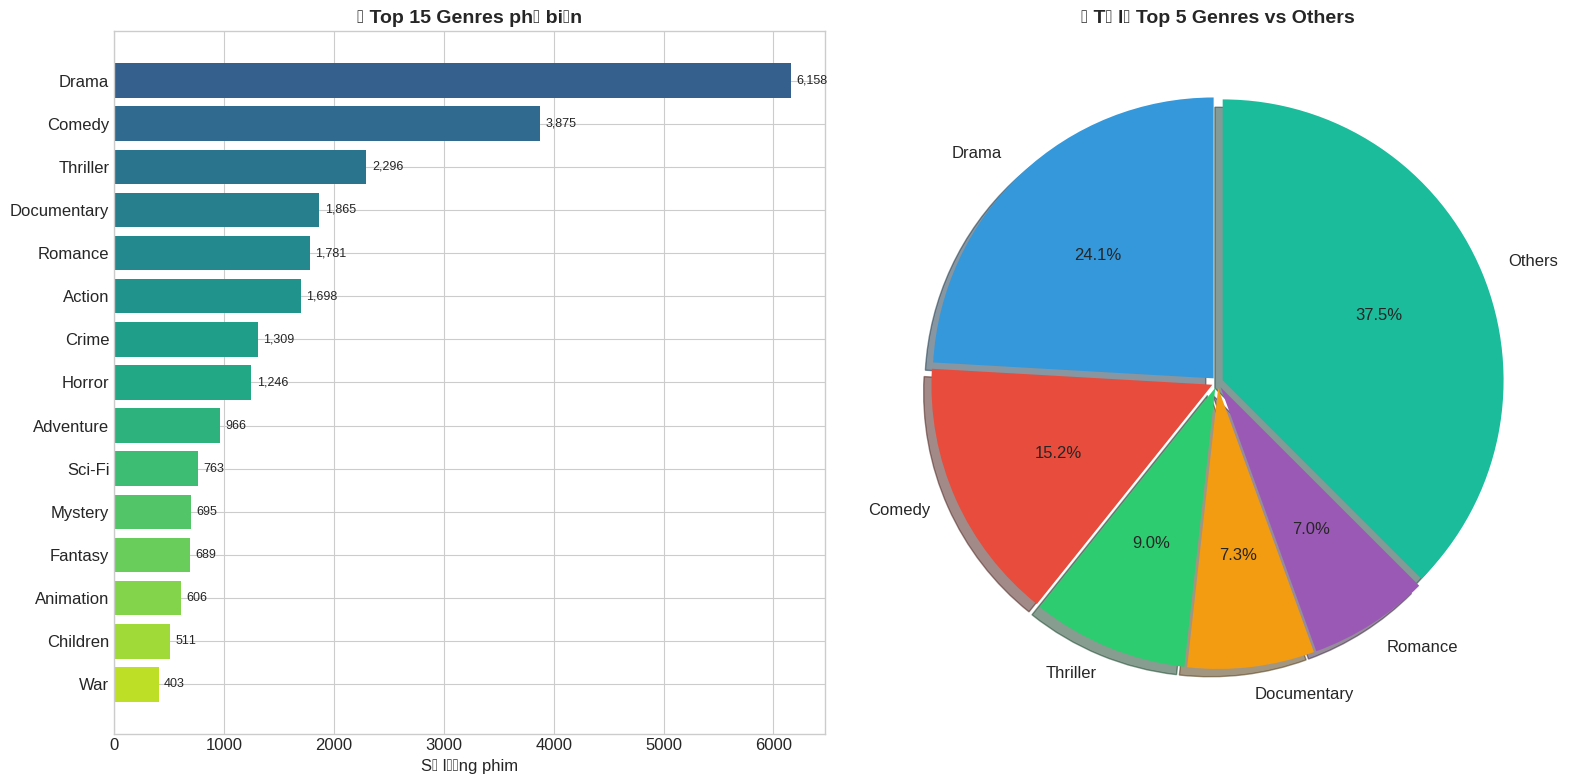


📊 Tổng số genres: 20
💾 Đã lưu: viz_top_genres.png


In [10]:
# ==========================================
# CELL 10: TOP GENRES PHỔ BIẾN
# ==========================================
# Giải thích:
# - Horizontal bar chart cho thấy genres phổ biến nhất
# - Mỗi phim có thể thuộc nhiều genres
# - Drama và Comedy thường dẫn đầu

# Tách và đếm genres
all_genres = []
for genres in movies_df['genres'].dropna():
    all_genres.extend(genres.split('|'))

genre_counts = pd.Series(all_genres).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1. Horizontal bar chart - Top 15 genres
ax1 = axes[0]
top_genres = genre_counts.head(15)
colors_gradient = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_genres)))
ax1.barh(top_genres.index[::-1], top_genres.values[::-1], color=colors_gradient[::-1])
ax1.set_xlabel('Số lượng phim')
ax1.set_title('🎭 Top 15 Genres phổ biến', fontsize=14, fontweight='bold')

# Thêm số liệu
for i, (genre, count) in enumerate(zip(top_genres.index[::-1], top_genres.values[::-1])):
    ax1.annotate(f'{count:,}', (count + 50, i), va='center', fontsize=9)

# 2. Pie chart - Top 5 genres
ax2 = axes[1]
top5_genres = genre_counts.head(5)
other_count = genre_counts[5:].sum()
pie_data = pd.concat([top5_genres, pd.Series({'Others': other_count})])

wedges, texts, autotexts = ax2.pie(
    pie_data.values,
    labels=pie_data.index,
    autopct='%1.1f%%',
    colors=COLORS,
    explode=[0.02]*len(pie_data),
    shadow=True,
    startangle=90
)
ax2.set_title('📊 Tỷ lệ Top 5 Genres vs Others', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/viz_top_genres.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Tổng số genres: {len(genre_counts)}")
print("💾 Đã lưu: viz_top_genres.png")

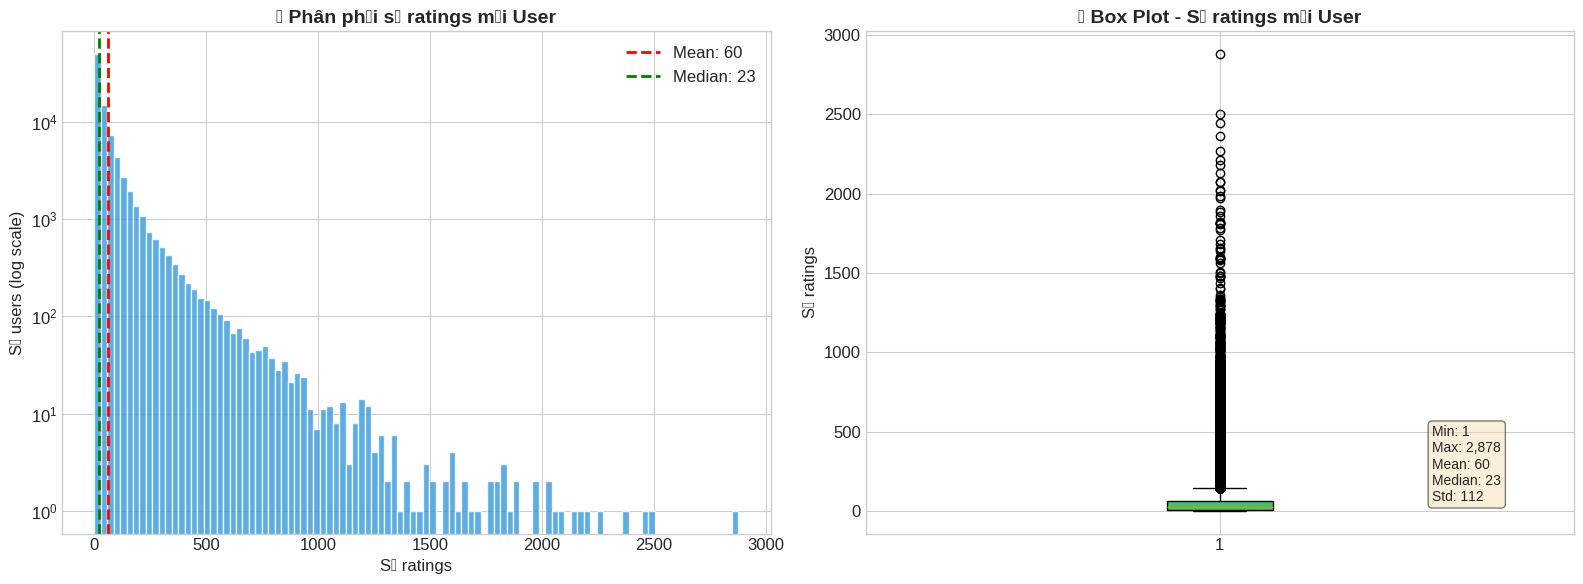


📊 Phân loại Users:
   - Casual (≤50 ratings): 61,395 users (69.9%)
   - Regular (51-200 ratings): 20,668 users (23.5%)
   - Power (>200 ratings): 5,788 users (6.6%)
💾 Đã lưu: viz_user_activity.png


In [11]:
# ==========================================
# CELL 11: PHÂN PHỐI HOẠT ĐỘNG USER
# ==========================================
# Giải thích:
# - Histogram số ratings mỗi user (log scale vì long-tail)
# - Phần lớn users chỉ rate ít phim (long-tail distribution)
# - Một số "power users" rate rất nhiều

# Đếm số ratings mỗi user
ratings_per_user = ratings_df.groupby('userId').size()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Histogram (log scale)
ax1 = axes[0]
ax1.hist(ratings_per_user.values, bins=100, color=COLORS[0], edgecolor='white', alpha=0.8)
ax1.set_xlabel('Số ratings')
ax1.set_ylabel('Số users (log scale)')
ax1.set_yscale('log')
ax1.set_title('👤 Phân phối số ratings mỗi User', fontsize=14, fontweight='bold')
ax1.axvline(x=ratings_per_user.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {ratings_per_user.mean():.0f}')
ax1.axvline(x=ratings_per_user.median(), color='green', linestyle='--', linewidth=2,
            label=f'Median: {ratings_per_user.median():.0f}')
ax1.legend()

# 2. Box plot
ax2 = axes[1]
bp = ax2.boxplot(ratings_per_user.values, vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor(COLORS[2])
ax2.set_ylabel('Số ratings')
ax2.set_title('📦 Box Plot - Số ratings mỗi User', fontsize=14, fontweight='bold')

# Thêm statistics
stats_text = f"""Min: {ratings_per_user.min()}
Max: {ratings_per_user.max():,}
Mean: {ratings_per_user.mean():.0f}
Median: {ratings_per_user.median():.0f}
Std: {ratings_per_user.std():.0f}"""
ax2.text(1.3, ratings_per_user.quantile(0.75), stats_text, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/viz_user_activity.png', dpi=150, bbox_inches='tight')
plt.show()

# Phân loại users
casual_users = (ratings_per_user <= 50).sum()
regular_users = ((ratings_per_user > 50) & (ratings_per_user <= 200)).sum()
power_users = (ratings_per_user > 200).sum()

print(f"\n📊 Phân loại Users:")
print(f"   - Casual (≤50 ratings): {casual_users:,} users ({casual_users/n_users*100:.1f}%)")
print(f"   - Regular (51-200 ratings): {regular_users:,} users ({regular_users/n_users*100:.1f}%)")
print(f"   - Power (>200 ratings): {power_users:,} users ({power_users/n_users*100:.1f}%)")
print("💾 Đã lưu: viz_user_activity.png")

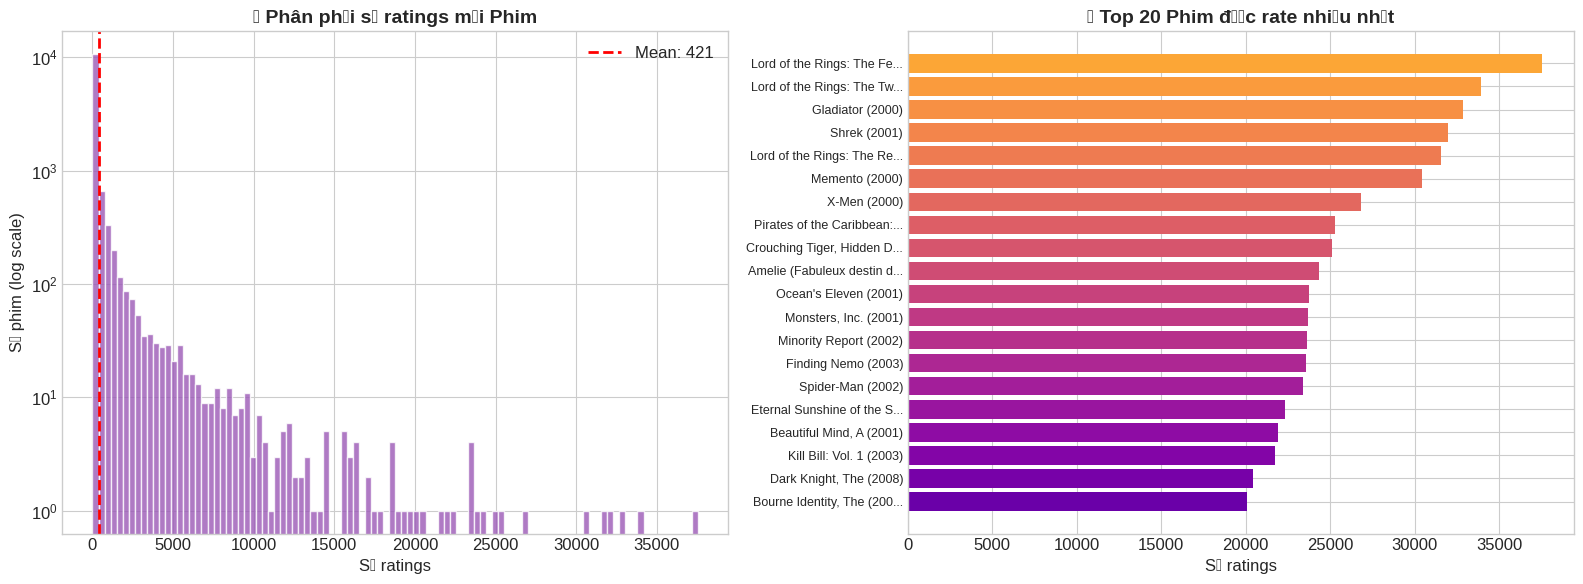


📊 Phim được rate nhiều nhất: Lord of the Rings: The Fellowship of the Ring, The (2001)
   Số ratings: 37,553
💾 Đã lưu: viz_movie_popularity.png


In [12]:
# ==========================================
# CELL 12: PHÂN PHỐI ĐỘ PHỔ BIẾN CỦA PHIM
# ==========================================
# Giải thích:
# - Histogram số ratings mỗi phim
# - Long-tail: ít phim rất phổ biến, nhiều phim ít được rate
# - Top 20 phim được rate nhiều nhất

# Đếm số ratings mỗi phim
ratings_per_movie = ratings_df.groupby('movieId').size()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Histogram
ax1 = axes[0]
ax1.hist(ratings_per_movie.values, bins=100, color=COLORS[4], edgecolor='white', alpha=0.8)
ax1.set_xlabel('Số ratings')
ax1.set_ylabel('Số phim (log scale)')
ax1.set_yscale('log')
ax1.set_title('🎬 Phân phối số ratings mỗi Phim', fontsize=14, fontweight='bold')
ax1.axvline(x=ratings_per_movie.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {ratings_per_movie.mean():.0f}')
ax1.legend()

# 2. Top 20 phim được rate nhiều nhất
ax2 = axes[1]
top20_movies = ratings_per_movie.nlargest(20)
top20_titles = movies_df[movies_df['movieId'].isin(top20_movies.index)].set_index('movieId')['title']
top20_titles = top20_titles[top20_movies.index]  # Đảm bảo đúng thứ tự

# Rút gọn title
short_titles = [t[:25] + '...' if len(t) > 25 else t for t in top20_titles.values]

colors_gradient = plt.cm.plasma(np.linspace(0.2, 0.8, 20))
ax2.barh(range(20), top20_movies.values[::-1], color=colors_gradient)
ax2.set_yticks(range(20))
ax2.set_yticklabels(short_titles[::-1], fontsize=9)
ax2.set_xlabel('Số ratings')
ax2.set_title('🏆 Top 20 Phim được rate nhiều nhất', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/viz_movie_popularity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Phim được rate nhiều nhất: {top20_titles.iloc[0]}")
print(f"   Số ratings: {top20_movies.iloc[0]:,}")
print("💾 Đã lưu: viz_movie_popularity.png")

   Đã xử lý 1,000,000 ratings...
   Đã xử lý 2,000,000 ratings...
   Đã xử lý 3,000,000 ratings...
   Đã xử lý 4,000,000 ratings...
   Đã xử lý 5,000,000 ratings...


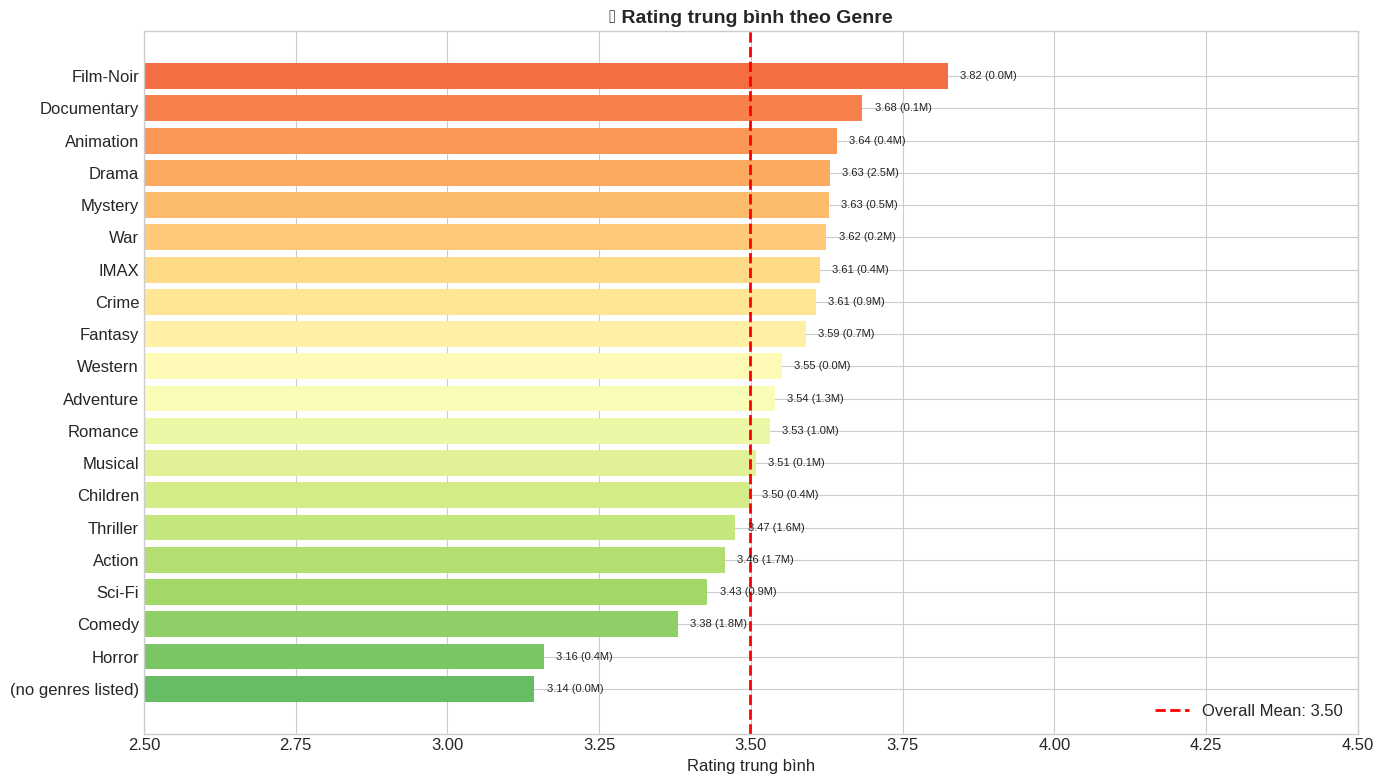


📊 Genre có rating cao nhất: Film-Noir (3.82)
📊 Genre có rating thấp nhất: (no genres listed) (3.14)
💾 Đã lưu: viz_rating_by_genre.png


In [13]:
# ==========================================
# CELL 13: RATING TRUNG BÌNH THEO GENRE
# ==========================================
# Giải thích:
# - Tính rating trung bình cho mỗi genre
# - Giúp hiểu genre nào được đánh giá cao/thấp
# - Film-Noir và Documentary thường có rating cao nhất

# Merge ratings với movies
ratings_with_genres = ratings_df.merge(movies_df[['movieId', 'genres']], on='movieId')

# Tính rating trung bình cho mỗi genre
genre_ratings = {}
for idx, row in ratings_with_genres.iterrows():
    if pd.notna(row['genres']):
        for genre in row['genres'].split('|'):
            if genre not in genre_ratings:
                genre_ratings[genre] = []
            genre_ratings[genre].append(row['rating'])
    if idx % 1000000 == 0 and idx > 0:
        print(f"   Đã xử lý {idx:,} ratings...")

genre_avg_ratings = {g: np.mean(r) for g, r in genre_ratings.items()}
genre_count_ratings = {g: len(r) for g, r in genre_ratings.items()}

# Tạo DataFrame
genre_stats = pd.DataFrame({
    'genre': list(genre_avg_ratings.keys()),
    'avg_rating': list(genre_avg_ratings.values()),
    'count': list(genre_count_ratings.values())
}).sort_values('avg_rating', ascending=False)

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(14, 8))

colors_gradient = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(genre_stats)))
bars = ax.barh(genre_stats['genre'].values[::-1], genre_stats['avg_rating'].values[::-1],
               color=colors_gradient[::-1])

ax.axvline(x=ratings_df['rating'].mean(), color='red', linestyle='--', linewidth=2,
           label=f"Overall Mean: {ratings_df['rating'].mean():.2f}")
ax.set_xlabel('Rating trung bình')
ax.set_title('⭐ Rating trung bình theo Genre', fontsize=14, fontweight='bold')
ax.set_xlim(2.5, 4.5)
ax.legend(loc='lower right')

# Thêm số liệu
for i, (genre, avg_r, count) in enumerate(zip(genre_stats['genre'].values[::-1],
                                              genre_stats['avg_rating'].values[::-1],
                                              genre_stats['count'].values[::-1])):
    ax.annotate(f'{avg_r:.2f} ({count/1e6:.1f}M)', (avg_r + 0.02, i), va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/viz_rating_by_genre.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Genre có rating cao nhất: {genre_stats.iloc[0]['genre']} ({genre_stats.iloc[0]['avg_rating']:.2f})")
print(f"📊 Genre có rating thấp nhất: {genre_stats.iloc[-1]['genre']} ({genre_stats.iloc[-1]['avg_rating']:.2f})")
print("💾 Đã lưu: viz_rating_by_genre.png")

In [14]:
# ==========================================
# CELL 14: TỔNG KẾT VISUALIZATION
# ==========================================
# Giải thích:
# - Tạo summary figure với các thông tin quan trọng
# - Hiển thị tất cả charts đã vẽ

print("=" * 60)
print("📊 TỔNG KẾT VISUALIZATION")
print("=" * 60)

print(f"""
📁 Các file visualization đã lưu vào {MODEL_DIR}:
   1. viz_rating_distribution.png - Phân phối rating
   2. viz_movies_by_year.png - Số phim theo năm
   3. viz_top_genres.png - Top genres phổ biến
   4. viz_user_activity.png - Hoạt động user
   5. viz_movie_popularity.png - Độ phổ biến phim
   6. viz_rating_by_genre.png - Rating theo genre

📌 Key Insights:
   - Dataset chỉ chứa phim từ năm 2000 trở đi
   - Ratings nghiêng về cao (mean ≈ 3.5)
   - Drama và Comedy là 2 genres phổ biến nhất
   - Phần lớn users là "casual" (≤50 ratings)
   - Dữ liệu có tính long-tail (ít phim rất phổ biến)
""")

📊 TỔNG KẾT VISUALIZATION

📁 Các file visualization đã lưu vào /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project/modelsv2:
   1. viz_rating_distribution.png - Phân phối rating
   2. viz_movies_by_year.png - Số phim theo năm
   3. viz_top_genres.png - Top genres phổ biến
   4. viz_user_activity.png - Hoạt động user
   5. viz_movie_popularity.png - Độ phổ biến phim
   6. viz_rating_by_genre.png - Rating theo genre

📌 Key Insights:
   - Dataset chỉ chứa phim từ năm 2000 trở đi
   - Ratings nghiêng về cao (mean ≈ 3.5)
   - Drama và Comedy là 2 genres phổ biến nhất
   - Phần lớn users là "casual" (≤50 ratings)
   - Dữ liệu có tính long-tail (ít phim rất phổ biến)



---
# 5. Collaborative Filtering - SVD

## 5.1. Lý thuyết SVD (Singular Value Decomposition)

**Ý tưởng chính:** Phân tích ma trận User-Item thành tích của các ma trận nhỏ hơn.

$$R \approx P \times Q^T$$

Trong đó:
- $R$ : Ma trận ratings (m users × n items)
- $P$ : Ma trận user factors (m × k)
- $Q$ : Ma trận item factors (n × k)
- $k$ : Số latent factors (thường 50-200)

**Công thức dự đoán:**

$$\hat{r}_{ui} = \mu + b_u + b_i + p_u \cdot q_i$$

- $\mu$: Global mean rating
- $b_u$: User bias
- $b_i$: Item bias
- $p_u \cdot q_i$: Dot product của latent vectors

In [15]:
# ==========================================
# CELL 15: CHUẨN BỊ DỮ LIỆU CHO SURPRISE
# ==========================================
# Giải thích:
# - Surprise library cần dữ liệu ở format đặc biệt
# - Reader định nghĩa rating_scale (0.5 - 5.0)
# - Dataset.load_from_df() chuyển pandas DataFrame sang Surprise format
# - train_test_split chia dữ liệu theo tỷ lệ 80-20

print("=" * 60)
print("📊 CHUẨN BỊ DỮ LIỆU CHO SURPRISE")
print("=" * 60)

# Định nghĩa rating scale
reader = Reader(rating_scale=(0.5, 5.0))

# Chuyển sang format Surprise
# Chỉ cần 3 columns: userId, movieId, rating
data = Dataset.load_from_df(
    ratings_df[['userId', 'movieId', 'rating']],
    reader
)

# Chia train/test (80-20)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print(f"\n📌 Training set: {trainset.n_ratings:,} ratings")
print(f"📌 Test set: {len(testset):,} ratings")
print(f"📌 Số users: {trainset.n_users:,}")
print(f"📌 Số items: {trainset.n_items:,}")

📊 CHUẨN BỊ DỮ LIỆU CHO SURPRISE

📌 Training set: 4,225,696 ratings
📌 Test set: 1,056,425 ratings
📌 Số users: 87,006
📌 Số items: 12,135


## 5.2. Training SVD Model

**Hyperparameters chính:**
- `n_factors`: Số latent factors (default: 100)
- `n_epochs`: Số epochs training (default: 20)
- `lr_all`: Learning rate (default: 0.005)
- `reg_all`: Regularization để tránh overfitting (default: 0.02)

**Thời gian training:** ~5-15 phút tùy thuộc vào kích thước dữ liệu.

In [16]:
# ==========================================
# CELL 16: TRAIN SVD MODEL
# ==========================================
# Giải thích:
# - n_factors=100: Sử dụng 100 đặc trưng ẩn (latent features)
# - n_epochs=20: Train 20 vòng lặp
# - random_state=42: Đảm bảo kết quả có thể reproduce
# - verbose=True: Hiển thị tiến trình training

print("=" * 60)
print("🚀 TRAINING SVD MODEL")
print("=" * 60)

start_time = time.time()

# Khởi tạo SVD với hyperparameters
svd_model = SVD(
    n_factors=100,    # Số latent factors
    n_epochs=20,      # Số epochs
    lr_all=0.005,     # Learning rate
    reg_all=0.02,     # Regularization
    random_state=42,
    verbose=True
)

# Train model
print("\n📈 Bắt đầu training...")
svd_model.fit(trainset)

train_time = time.time() - start_time
print(f"\n✅ Training hoàn tất!")
print(f"⏱️ Thời gian training: {train_time:.2f} giây ({train_time/60:.1f} phút)")

🚀 TRAINING SVD MODEL

📈 Bắt đầu training...
Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19

✅ Training hoàn tất!
⏱️ Thời gian training: 72.25 giây (1.2 phút)


## 5.3. Đánh giá SVD Model

**Metrics đánh giá:**
- **RMSE (Root Mean Square Error):** Sai số căn bậc hai trung bình
- **MAE (Mean Absolute Error):** Sai số tuyệt đối trung bình

**Mục tiêu:** RMSE và MAE càng thấp càng tốt. Thường RMSE < 1.0 là acceptable.

In [17]:
# ==========================================
# CELL 17: ĐÁNH GIÁ SVD MODEL
# ==========================================
# Giải thích:
# - model.test(testset): Dự đoán trên tập test
# - accuracy.rmse(): Tính Root Mean Square Error
# - accuracy.mae(): Tính Mean Absolute Error
# - RMSE < 1.0 được coi là tốt cho rating scale 0.5-5.0

print("=" * 60)
print("📊 ĐÁNH GIÁ SVD MODEL")
print("=" * 60)

# Dự đoán trên test set
predictions = svd_model.test(testset)

# Tính metrics
rmse = accuracy.rmse(predictions, verbose=True)
mae = accuracy.mae(predictions, verbose=True)

print(f"\n📌 Kết quả trên Test Set:")
print(f"   - RMSE: {rmse:.4f}")
print(f"   - MAE: {mae:.4f}")

# Đánh giá
if rmse < 0.9:
    print(f"\n🏆 Excellent! RMSE < 0.9")
elif rmse < 1.0:
    print(f"\n✅ Good! RMSE < 1.0")
else:
    print(f"\n⚠️ Có thể cần tune hyperparameters (RMSE >= 1.0)")

📊 ĐÁNH GIÁ SVD MODEL
RMSE: 0.7915
MAE:  0.5920

📌 Kết quả trên Test Set:
   - RMSE: 0.7915
   - MAE: 0.5920

🏆 Excellent! RMSE < 0.9


In [18]:
# ==========================================
# CELL 18: TEST DỰ ĐOÁN SVD
# ==========================================
# Giải thích:
# - Lấy ngẫu nhiên 1 user để test
# - Dự đoán rating cho các phim user chưa xem
# - Hiển thị top 10 phim được recommend

print("=" * 60)
print("🎯 TEST DỰ ĐOÁN SVD")
print("=" * 60)

# Chọn 1 user ngẫu nhiên
test_user_id = ratings_df['userId'].sample(1).values[0]
print(f"\n👤 User ID: {test_user_id}")

# Lấy danh sách phim user đã xem
user_watched = set(ratings_df[ratings_df['userId'] == test_user_id]['movieId'])
print(f"📌 Số phim đã xem: {len(user_watched)}")

# Dự đoán cho các phim chưa xem
all_movie_ids = movies_df['movieId'].unique()
unwatched = [mid for mid in all_movie_ids if mid not in user_watched]

predictions = []
for movie_id in unwatched[:1000]:  # Giới hạn 1000 phim để nhanh
    pred = svd_model.predict(test_user_id, movie_id)
    predictions.append((movie_id, pred.est))

# Sort theo predicted rating
predictions.sort(key=lambda x: x[1], reverse=True)

# Hiển thị top 10
print(f"\n🎬 Top 10 Phim Đề Xuất cho User {test_user_id}:")
print("-" * 60)
for i, (movie_id, pred_rating) in enumerate(predictions[:10], 1):
    title = movies_df[movies_df['movieId'] == movie_id]['title'].values[0]
    print(f"{i:2}. {title[:50]}")
    print(f"    → Predicted Rating: {pred_rating:.2f}")

🎯 TEST DỰ ĐOÁN SVD

👤 User ID: 6056
📌 Số phim đã xem: 92

🎬 Top 10 Phim Đề Xuất cho User 6056:
------------------------------------------------------------
 1. Mostly Martha (Bella Martha) (2001)
    → Predicted Rating: 4.40
 2. No Man's Land (2001)
    → Predicted Rating: 4.35
 3. Endurance: Shackleton's Legendary Antarctic Expedi
    → Predicted Rating: 4.34
 4. Children Underground (2001)
    → Predicted Rating: 4.32
 5. Chocolat (2000)
    → Predicted Rating: 4.28
 6. Mulholland Drive (2001)
    → Predicted Rating: 4.27
 7. Stevie (2002)
    → Predicted Rating: 4.27
 8. Nowhere in Africa (Nirgendwo in Afrika) (2001)
    → Predicted Rating: 4.26
 9. Talk to Her (Hable con Ella) (2002)
    → Predicted Rating: 4.26
10. You Can Count on Me (2000)
    → Predicted Rating: 4.25


---
# 6. Content-Based Filtering

## 6.1. Lý thuyết Content-Based

**Ý tưởng:** Đề xuất phim có nội dung tương tự với phim user đã thích.

**Phương pháp:**
1. **TF-IDF (Term Frequency - Inverse Document Frequency):**
   - Chuyển genres text thành vector số
   - TF: Tần suất của term trong document
   - IDF: Độ hiếm của term trong toàn bộ corpus

2. **Cosine Similarity:**
   $$sim(A, B) = \frac{A \cdot B}{||A|| \times ||B||}$$
   - Đo độ tương tự giữa 2 vectors
   - Giá trị từ 0 (khác hoàn toàn) đến 1 (giống hệt)

In [19]:
# ==========================================
# CELL 19: CHUẨN BỊ DỮ LIỆU CHO CONTENT-BASED
# ==========================================
# Giải thích:
# - Chuyển genres từ format "Action|Adventure" thành "Action Adventure"
# - TF-IDF vectorizer chuyển text thành vector số
# - Mỗi phim được biểu diễn bằng 1 vector trong không gian genres

print("=" * 60)
print("🎭 CHUẨN BỊ CONTENT-BASED FILTERING")
print("=" * 60)

# Tạo bản copy để xử lý
movies_cb = movies_df.copy()

# Chuyển genres từ "Action|Adventure" thành "Action Adventure"
movies_cb['genres_str'] = movies_cb['genres'].fillna('').str.replace('|', ' ', regex=False)

print(f"\n📌 Sample genres_str:")
for i, row in movies_cb.head(5).iterrows():
    print(f"   {row['title'][:40]}: {row['genres_str']}")

# Tạo mappings movieId <-> index
movie_id_to_index = {}
index_to_movie_id = {}
for idx, row in movies_cb.iterrows():
    movie_id_to_index[row['movieId']] = idx
    index_to_movie_id[idx] = row['movieId']

print(f"\n📌 Đã tạo mappings cho {len(movie_id_to_index):,} phim")

🎭 CHUẨN BỊ CONTENT-BASED FILTERING

📌 Sample genres_str:
   Yards, The (2000): Crime Drama
   Next Friday (2000): Comedy
   Supernova (2000): Adventure Sci-Fi Thriller
   Down to You (2000): Comedy Romance
   Wirey Spindell (2000): Comedy

📌 Đã tạo mappings cho 12,746 phim


In [20]:
# ==========================================
# CELL 20: TF-IDF VECTORIZATION
# ==========================================
# Giải thích:
# - TfidfVectorizer chuyển text thành sparse matrix
# - stop_words='english' loại bỏ các từ phổ biến (the, a, is, ...)
# - Kết quả: mỗi phim là 1 vector với dimension = số genres khác nhau

print("=" * 60)
print("📐 TF-IDF VECTORIZATION")
print("=" * 60)

start_time = time.time()

# Tạo TF-IDF vectorizer
tfidf = TfidfVectorizer(
    stop_words='english',  # Loại bỏ stopwords
    min_df=5,              # Bỏ qua term xuất hiện < 5 lần
    max_df=0.95            # Bỏ qua term xuất hiện > 95% documents
)

# Fit và transform
tfidf_matrix = tfidf.fit_transform(movies_cb['genres_str'])

print(f"\n📌 TF-IDF Matrix shape: {tfidf_matrix.shape}")
print(f"📌 Số features (genres): {len(tfidf.get_feature_names_out())}")
print(f"📌 Feature names: {list(tfidf.get_feature_names_out())}")

vec_time = time.time() - start_time
print(f"\n⏱️ Thời gian vectorization: {vec_time:.2f} giây")

📐 TF-IDF VECTORIZATION

📌 TF-IDF Matrix shape: (12746, 23)
📌 Số features (genres): 23
📌 Feature names: ['action', 'adventure', 'animation', 'children', 'comedy', 'crime', 'documentary', 'drama', 'fantasy', 'fi', 'film', 'genres', 'horror', 'imax', 'listed', 'musical', 'mystery', 'noir', 'romance', 'sci', 'thriller', 'war', 'western']

⏱️ Thời gian vectorization: 0.05 giây


In [21]:
# ==========================================
# CELL 21: TÍNH COSINE SIMILARITY
# ==========================================
# Giải thích:
# - cosine_similarity tính độ tương tự giữa tất cả cặp phim
# - Kết quả: ma trận vuông N x N (N = số phim)
# - Giá trị từ 0 (khác hoàn toàn) đến 1 (giống hệt)
# - Lưu ý: có thể tốn nhiều RAM nếu N lớn

print("=" * 60)
print("📐 TÍNH COSINE SIMILARITY")
print("=" * 60)

start_time = time.time()

# Giới hạn số phim để tránh out of memory
MAX_MOVIES_CB = min(15000, len(movies_cb))
print(f"\n📌 Tính similarity cho {MAX_MOVIES_CB:,} phim...")

# Tính cosine similarity
cosine_sim = cosine_similarity(
    tfidf_matrix[:MAX_MOVIES_CB],
    tfidf_matrix[:MAX_MOVIES_CB]
)

sim_time = time.time() - start_time
print(f"\n✅ Cosine Similarity Matrix:")
print(f"   - Shape: {cosine_sim.shape}")
print(f"   - Memory: {cosine_sim.nbytes / 1e6:.1f} MB")
print(f"\n⏱️ Thời gian tính: {sim_time:.2f} giây")

📐 TÍNH COSINE SIMILARITY

📌 Tính similarity cho 12,746 phim...

✅ Cosine Similarity Matrix:
   - Shape: (12746, 12746)
   - Memory: 1299.7 MB

⏱️ Thời gian tính: 2.06 giây


In [22]:
# ==========================================
# CELL 22: TEST CONTENT-BASED FILTERING
# ==========================================
# Giải thích:
# - Hàm get_similar_movies() trả về N phim tương tự nhất
# - Dựa trên cosine similarity đã tính
# - Test với 1 phim cụ thể

def get_similar_movies(movie_id, n=10):
    """
    Trả về N phim tương tự nhất với movie_id.

    Args:
        movie_id: ID của phim cần tìm tương tự
        n: Số phim trả về

    Returns:
        List of tuples (movie_id, title, similarity_score)
    """
    if movie_id not in movie_id_to_index:
        return []

    idx = movie_id_to_index[movie_id]

    if idx >= cosine_sim.shape[0]:
        return []

    # Lấy similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort theo similarity (bỏ qua phim gốc)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]  # Bỏ phim gốc (index 0)

    # Lấy thông tin phim
    results = []
    for i, score in sim_scores:
        mid = index_to_movie_id[i]
        title = movies_cb[movies_cb['movieId'] == mid]['title'].values[0]
        results.append((mid, title, score))

    return results

# TEST với phim "The Dark Knight" hoặc phim đầu tiên trong dataset
print("=" * 60)
print("🎯 TEST CONTENT-BASED FILTERING")
print("=" * 60)

# Tìm 1 phim phổ biến để test
popular_movies = ratings_df.groupby('movieId').size().nlargest(10)
test_movie_id = popular_movies.index[0]
test_movie_title = movies_df[movies_df['movieId'] == test_movie_id]['title'].values[0]

print(f"\n🎬 Phim gốc: {test_movie_title}")
print(f"   Genres: {movies_df[movies_df['movieId'] == test_movie_id]['genres'].values[0]}")

# Lấy phim tương tự
similar = get_similar_movies(test_movie_id, n=10)

print(f"\n🎭 Top 10 Phim Tương Tự:")
print("-" * 60)
for i, (mid, title, score) in enumerate(similar, 1):
    genres = movies_df[movies_df['movieId'] == mid]['genres'].values[0]
    print(f"{i:2}. {title[:45]}")
    print(f"    Genres: {genres}")
    print(f"    Similarity: {score:.4f}")

🎯 TEST CONTENT-BASED FILTERING

🎬 Phim gốc: Lord of the Rings: The Fellowship of the Ring, The (2001)
   Genres: Adventure|Fantasy

🎭 Top 10 Phim Tương Tự:
------------------------------------------------------------
 1. Lord of the Rings: The Fellowship of the Ring
    Genres: Adventure|Fantasy
    Similarity: 1.0000
 2. Harry Potter and the Chamber of Secrets (2002
    Genres: Adventure|Fantasy
    Similarity: 1.0000
 3. Lord of the Rings: The Two Towers, The (2002)
    Genres: Adventure|Fantasy
    Similarity: 1.0000
 4. Strings (2004)
    Genres: Adventure|Fantasy
    Similarity: 1.0000
 5. Dinotopia (2002)
    Genres: Adventure|Fantasy
    Similarity: 1.0000
 6. Fire and Ice (2008)
    Genres: Adventure|Fantasy
    Similarity: 1.0000
 7. Inkheart (2008)
    Genres: Adventure|Fantasy
    Similarity: 1.0000
 8. Percy Jackson & the Olympians: The Lightning 
    Genres: Adventure|Fantasy
    Similarity: 1.0000
 9. Almighty Thor (2011)
    Genres: Adventure|Fantasy
    Similarity: 1.00

---
# 7. Đánh giá Model

## 7.1. So sánh các phương pháp

| Phương pháp | Ưu điểm | Nhược điểm |
|-------------|---------|------------|
| **SVD** | Cá nhân hóa cao | Cold-start problem |
| **Content-Based** | Không cần dữ liệu user khác | Thiếu diversity |

In [23]:
# ==========================================
# CELL 23: CROSS-VALIDATION SVD
# ==========================================
# Giải thích:
# - Cross-validation đánh giá model trên nhiều folds
# - Giúp đánh giá model robust hơn
# - cv=5 nghĩa là chia dữ liệu thành 5 phần

print("=" * 60)
print("🔄 CROSS-VALIDATION (5-Fold)")
print("=" * 60)

print("\n⏳ Đang chạy cross-validation...")
start_time = time.time()

# Cross-validate SVD
cv_results = cross_validate(
    SVD(n_factors=100, n_epochs=20, random_state=42),
    data,
    measures=['RMSE', 'MAE'],
    cv=5,
    verbose=True
)

cv_time = time.time() - start_time

print(f"\n📊 Kết quả Cross-Validation:")
print(f"   - RMSE: {np.mean(cv_results['test_rmse']):.4f} (+/- {np.std(cv_results['test_rmse']):.4f})")
print(f"   - MAE: {np.mean(cv_results['test_mae']):.4f} (+/- {np.std(cv_results['test_mae']):.4f})")
print(f"\n⏱️ Thời gian: {cv_time:.1f} giây")

🔄 CROSS-VALIDATION (5-Fold)

⏳ Đang chạy cross-validation...
Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.7917  0.7916  0.7912  0.7923  0.7910  0.7916  0.0004  
MAE (testset)     0.5923  0.5925  0.5922  0.5927  0.5918  0.5923  0.0003  
Fit time          72.46   76.26   75.71   75.91   75.45   75.16   1.38    
Test time         16.49   17.65   17.95   19.38   17.39   17.77   0.94    

📊 Kết quả Cross-Validation:
   - RMSE: 0.7916 (+/- 0.0004)
   - MAE: 0.5923 (+/- 0.0003)

⏱️ Thời gian: 529.4 giây


---
# 8. Lưu Model & Kết luận

## 8.1. Lưu các model đã train

Sử dụng `joblib` để serialize các model:
- SVD model
- Cosine similarity matrix
- Mappings (movieId <-> index)
- Movies DataFrame

In [24]:
# ==========================================
# CELL 24: LƯU MODELS
# ==========================================
# Giải thích:
# - Lưu tất cả models và data cần thiết
# - Để AI Service có thể load và sử dụng
# - joblib hiệu quả hơn pickle cho numpy arrays

print("=" * 60)
print("💾 LƯU MODELS")
print("=" * 60)

# 1. SVD Model
svd_path = f'{MODEL_DIR}/svd_model.pkl'
joblib.dump(svd_model, svd_path)
print(f"✅ Đã lưu SVD model: {svd_path}")

# 2. Cosine Similarity Matrix
cosine_path = f'{MODEL_DIR}/cosine_sim_matrix.pkl'
joblib.dump(cosine_sim, cosine_path)
print(f"✅ Đã lưu Cosine Similarity: {cosine_path}")

# 3. Content-Based Mappings
mappings_path = f'{MODEL_DIR}/content_mappings.pkl'
joblib.dump({
    'movie_id_to_index': movie_id_to_index,
    'index_to_movie_id': index_to_movie_id
}, mappings_path)
print(f"✅ Đã lưu Mappings: {mappings_path}")

# 4. Movies DataFrame
movies_path = f'{MODEL_DIR}/movies_df.pkl'
joblib.dump(movies_df, movies_path)
print(f"✅ Đã lưu Movies DataFrame: {movies_path}")

# 5. Ratings DataFrame (for collaborative filtering)
ratings_path = f'{MODEL_DIR}/ratings_df.pkl'
joblib.dump(ratings_df, ratings_path)
print(f"✅ Đã lưu Ratings DataFrame: {ratings_path}")

# Tổng kích thước
print(f"\n📁 Tổng dung lượng models:")
total_size = 0
for f in [svd_path, cosine_path, mappings_path, movies_path, ratings_path]:
    size = os.path.getsize(f) / 1e6
    total_size += size
    print(f"   {os.path.basename(f)}: {size:.2f} MB")
print(f"   TOTAL: {total_size:.2f} MB")

💾 LƯU MODELS
✅ Đã lưu SVD model: /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project/modelsv2/svd_model.pkl
✅ Đã lưu Cosine Similarity: /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project/modelsv2/cosine_sim_matrix.pkl
✅ Đã lưu Mappings: /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project/modelsv2/content_mappings.pkl
✅ Đã lưu Movies DataFrame: /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project/modelsv2/movies_df.pkl
✅ Đã lưu Ratings DataFrame: /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project/modelsv2/ratings_df.pkl

📁 Tổng dung lượng models:
   svd_model.pkl: 198.83 MB
   cosine_sim_matrix.pkl: 1299.68 MB
   content_mappings.pkl: 0.19 MB
   movies_df.pkl: 0.68 MB
   ratings_df.pkl: 240.86 MB
   TOTAL: 1740.24 MB


In [25]:
# ==========================================
# CELL 25: KẾT LUẬN
# ==========================================

print("=" * 60)
print("📋 TỔNG KẾT")
print("=" * 60)

print(f"""
🎬 MOVIE RECOMMENDATION SYSTEM - TRAINING COMPLETE!

📊 Dataset Statistics:
   - Số phim: {len(movies_df):,} (chỉ từ năm 2000+)
   - Số ratings: {len(ratings_df):,}
   - Số users: {ratings_df['userId'].nunique():,}

🤖 Models Trained:
   1. SVD (Collaborative Filtering)
      - RMSE: {rmse:.4f}
      - MAE: {mae:.4f}

   2. Content-Based (TF-IDF + Cosine Similarity)
      - Similarity matrix: {cosine_sim.shape}

💾 Models Saved:
   - {MODEL_DIR}/svd_model.pkl
   - {MODEL_DIR}/cosine_sim_matrix.pkl
   - {MODEL_DIR}/content_mappings.pkl
   - {MODEL_DIR}/movies_df.pkl
   - {MODEL_DIR}/ratings_df.pkl

📈 Visualizations Saved:
   - viz_rating_distribution.png
   - viz_movies_by_year.png
   - viz_top_genres.png
   - viz_user_activity.png
   - viz_movie_popularity.png
   - viz_rating_by_genre.png

🚀 Next Steps:
   1. Copy thư mục models/ vào ai-service/models/
   2. Chạy AI Service: python main.py
   3. Test API endpoints
""")

📋 TỔNG KẾT

🎬 MOVIE RECOMMENDATION SYSTEM - TRAINING COMPLETE!

📊 Dataset Statistics:
   - Số phim: 12,746 (chỉ từ năm 2000+)
   - Số ratings: 5,282,121
   - Số users: 87,851

🤖 Models Trained:
   1. SVD (Collaborative Filtering)
      - RMSE: 0.7915
      - MAE: 0.5920
   
   2. Content-Based (TF-IDF + Cosine Similarity)
      - Similarity matrix: (12746, 12746)

💾 Models Saved:
   - /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project/modelsv2/svd_model.pkl
   - /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project/modelsv2/cosine_sim_matrix.pkl
   - /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project/modelsv2/content_mappings.pkl
   - /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project/modelsv2/movies_df.pkl
   - /content/drive/MyDrive/0-CTU/1-Documents/3-II/CT255H - BI/project/modelsv2/ratings_df.pkl

📈 Visualizations Saved:
   - viz_rating_distribution.png
   - viz_movies_by_year.png
   - viz_top_genres.png
   - viz_user_activit